In [3]:

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)



TensorFlow Version: 2.21.0


In [4]:
# ==========================================
# Dataset Paths
# ==========================================

train_dir = "dataset/Skin_Disease/train"
test_dir = "dataset/Skin_Disease/test"

print("Training Path :", train_dir)
print("Testing Path  :", test_dir)

print("\nTraining Classes :", os.listdir(train_dir))
print("Testing Classes  :", os.listdir(test_dir))

Training Path : dataset/Skin_Disease/train
Testing Path  : dataset/Skin_Disease/test

Training Classes : ['benign', 'malignant']
Testing Classes  : ['benign', 'malignant']


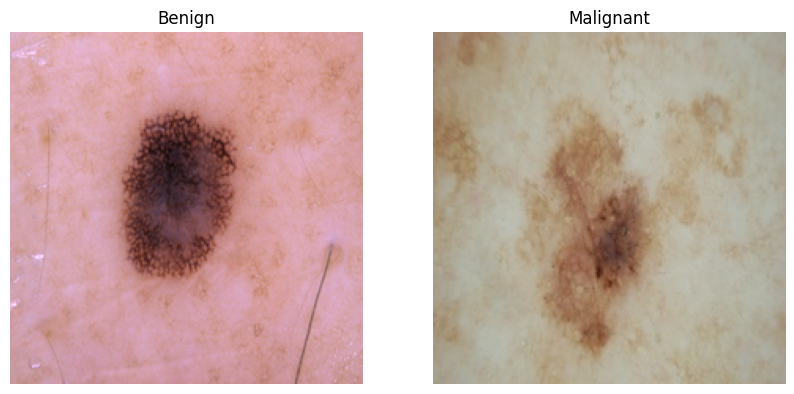

In [5]:
# ==========================================
# Display Sample Images
# ==========================================

import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

classes = ["benign", "malignant"]

plt.figure(figsize=(10, 5))

for i, cls in enumerate(classes):
    folder = os.path.join(train_dir, cls)
    img_name = os.listdir(folder)[0]   # First image from each class
    img_path = os.path.join(folder, img_name)

    img = image.load_img(img_path, target_size=(224, 224))

    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.title(cls.capitalize())
    plt.axis("off")

plt.show()

In [6]:
# ==========================================
# Image Data Generator
# ==========================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Testing data (only rescaling)
test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("ImageDataGenerator Created Successfully!")

ImageDataGenerator Created Successfully!


In [7]:
# ==========================================
# Load Training and Validation Data
# ==========================================

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

# ==========================================
# Load Testing Data
# ==========================================

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Data Loading Completed Successfully!")

Found 2110 images belonging to 2 classes.
Found 527 images belonging to 2 classes.
Found 660 images belonging to 2 classes.
Data Loading Completed Successfully!


In [8]:
# ==========================================
# Build MobileNetV2 Model
# ==========================================

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False


# Add our classifier layers
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.5)(x)

output = Dense(1, activation="sigmoid")(x)


model = Model(
    inputs=base_model.input,
    outputs=output
)


# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
# ==========================================
# Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "model/skin_disease.keras",
    monitor="val_accuracy",
    save_best_only=True
)

print("Callbacks Created Successfully!")

Callbacks Created Successfully!


In [12]:
# ==========================================
# Train Model
# ==========================================

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

print("Training Completed Successfully!")

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.6299 - loss: 0.6790 - val_accuracy: 0.7495 - val_loss: 0.5312
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.7502 - loss: 0.5024 - val_accuracy: 0.7552 - val_loss: 0.5008
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.7801 - loss: 0.4579 - val_accuracy: 0.7856 - val_loss: 0.4671
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.7915 - loss: 0.4508 - val_accuracy: 0.7837 - val_loss: 0.4731
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8104 - loss: 0.4209 - val_accuracy: 0.7780 - val_loss: 0.4718
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.8104 - loss: 0.4034 - val_accuracy: 0.7780 - val_loss: 0.4640
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 250s 4s/step - accuracy: 0.8246 - loss: 0.3949 - val_accuracy: 0.7989 - val_loss: 0.4463
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.8294 - loss: 0.3783 - val_accuracy: 0.7894 - val_los

In [15]:
# ==========================================
# Model Evaluation on Test Dataset
# ==========================================

test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 935ms/step - accuracy: 0.8545 - loss: 0.3418
Test Loss     : 0.34184134006500244
Test Accuracy : 0.8545454740524292


21/21 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step
Classification Report:

              precision    recall  f1-score   support

      benign       0.90      0.83      0.86       360
   malignant       0.81      0.88      0.85       300

    accuracy                           0.85       660
   macro avg       0.85      0.86      0.85       660
weighted avg       0.86      0.85      0.85       660



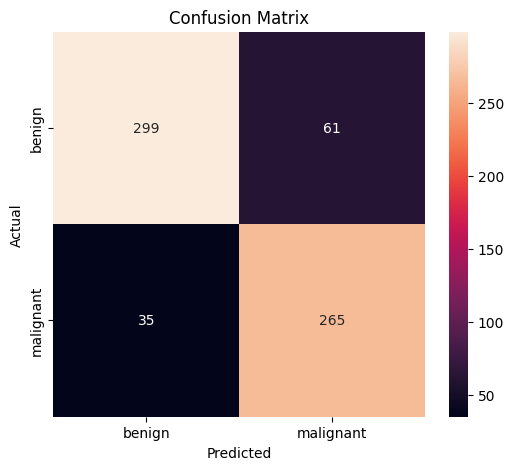

In [16]:
# ==========================================
# Classification Report & Confusion Matrix
# ==========================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predictions
predictions = model.predict(test_data)

# Convert probabilities to class labels
predicted_classes = (predictions > 0.5).astype(int).reshape(-1)

# Actual labels
true_classes = test_data.classes

# Class names
class_names = list(test_data.class_indices.keys())

print("Classification Report:\n")
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))


# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [22]:
malignant_probability = float(prediction[0][0])

if malignant_probability > 0.5:
    result = "Malignant"
    confidence = malignant_probability
else:
    result = "Benign"
    confidence = 1 - malignant_probability


print("Prediction :", result)
print("Confidence :", round(confidence*100,2), "%")

Prediction : Benign
Confidence : 62.0 %


In [18]:
import os

print(os.getcwd())
print(os.listdir())

D:\AI_CNN_Projects\Medical_Image_Diagnosis
['.env', '.gitignore', '.ipynb_checkpoints', 'app.py', 'Brain_MRI.ipynb', 'dataset', 'medical_img_pred.ipynb', 'model', 'prepare_brain_mri.py', 'prepare_skin_disease.py', 'README.md', 'reduce_dataset.py', 'reports.json', 'requirements.txt', 'Skin_Disease.ipynb', 'static', 'templates', 'uploads']


In [19]:
import os

for root, dirs, files in os.walk("dataset/Skin_Disease"):
    for file in files[:5]:
        print(os.path.join(root, file))

dataset/Skin_Disease\test\benign\1.jpg
dataset/Skin_Disease\test\benign\10.jpg
dataset/Skin_Disease\test\benign\1003.jpg
dataset/Skin_Disease\test\benign\1006.jpg
dataset/Skin_Disease\test\benign\1013.jpg
dataset/Skin_Disease\test\malignant\1.jpg
dataset/Skin_Disease\test\malignant\1003.jpg
dataset/Skin_Disease\test\malignant\1005.jpg
dataset/Skin_Disease\test\malignant\1007.jpg
dataset/Skin_Disease\test\malignant\1009.jpg
dataset/Skin_Disease\train\benign\100.jpg
dataset/Skin_Disease\train\benign\1000.jpg
dataset/Skin_Disease\train\benign\1001.jpg
dataset/Skin_Disease\train\benign\1002.jpg
dataset/Skin_Disease\train\benign\1004.jpg
dataset/Skin_Disease\train\malignant\10.jpg
dataset/Skin_Disease\train\malignant\100.jpg
dataset/Skin_Disease\train\malignant\1000.jpg
dataset/Skin_Disease\train\malignant\1001.jpg
dataset/Skin_Disease\train\malignant\1002.jpg


In [20]:
img_path = "dataset/Skin_Disease/test/benign/1.jpg"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
Prediction : Benign
Confidence : 38.0 %


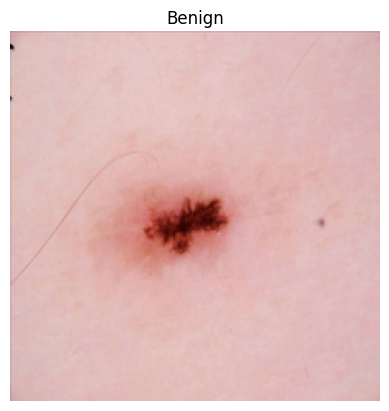

In [23]:
# ==========================================
# Single Image Prediction
# ==========================================

from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "dataset/Skin_Disease/test/benign/1.jpg"

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0


prediction = model.predict(img_array)

confidence = prediction[0][0]

if confidence > 0.5:
    result = "Malignant"
else:
    result = "Benign"


print("Prediction :", result)
print("Confidence :", round(float(confidence)*100,2), "%")


plt.imshow(img)
plt.axis("off")
plt.title(result)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
Prediction : Malignant
Confidence : 99.0 %


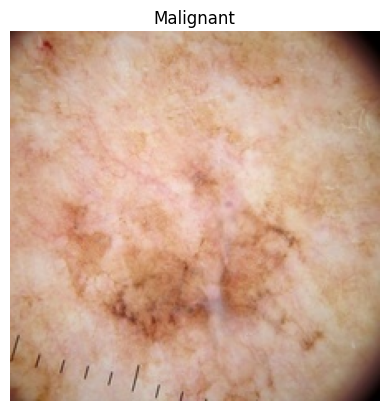

In [24]:
# ==========================================
# Single Image Prediction (Correct Version)
# ==========================================

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = "dataset/Skin_Disease/test/malignant/1.jpg"

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0


prediction = model.predict(img_array)

malignant_probability = float(prediction[0][0])
benign_probability = 1 - malignant_probability


if malignant_probability > benign_probability:
    result = "Malignant"
    confidence = malignant_probability
else:
    result = "Benign"
    confidence = benign_probability


print("Prediction :", result)
print("Confidence :", round(confidence*100,2), "%")


plt.imshow(img)
plt.axis("off")
plt.title(result)
plt.show()

In [25]:
# ==========================================
# Save Class Names
# ==========================================

class_names = list(test_data.class_indices.keys())

print("Class Names:", class_names)

# Save class names
with open("model/class_names.txt", "w") as file:
    for name in class_names:
        file.write(name + "\n")

print("Class names saved successfully!")

Class Names: ['benign', 'malignant']
Class names saved successfully!


In [26]:
# ==========================================
# Load Saved Model Test
# ==========================================

from tensorflow.keras.models import load_model

loaded_model = load_model("model/skin_disease.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!
